# Task 1: Data Cleaning & Preprocessing

## Objective

The objective of this task is to clean and prepare raw Titanic passenger data for machine learning.

## Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Data Preprocessing Steps

1. Import and explore the dataset
2. Check and handle missing values
3. Identify numerical and categorical features
4. Encode categorical variables
5. Detect outliers using boxplots
6. Remove outliers using the IQR method
7. Standardize numerical features
8. Verify the final preprocessed dataset
9. Save the cleaned dataset

## Dataset

The project uses the Titanic passenger dataset containing information about passengers and their survival status.

In [2]:
# Task 1: Data Cleaning & Preprocessing
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Load the Titanic dataset

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (891, 12)


In [4]:
# Display the first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Display basic information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
# Handle missing values

# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it contains too many missing values
df.drop("Cabin", axis=1, inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [8]:
# Verify missing values after cleaning

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [9]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns:
['Name', 'Sex', 'Ticket', 'Embarked']


C:\Users\iswar\AppData\Local\Temp\ipykernel_28948\3050033113.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [10]:
# Remove unnecessary identifier columns

df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

print("Unnecessary identifier columns removed.")
print("Remaining columns:")
print(df.columns.tolist())

Unnecessary identifier columns removed.
Remaining columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [11]:
# Convert categorical variables into numerical values
# using one-hot encoding

df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

print("Categorical variables encoded successfully!")
print(df.head())

Categorical variables encoded successfully!
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


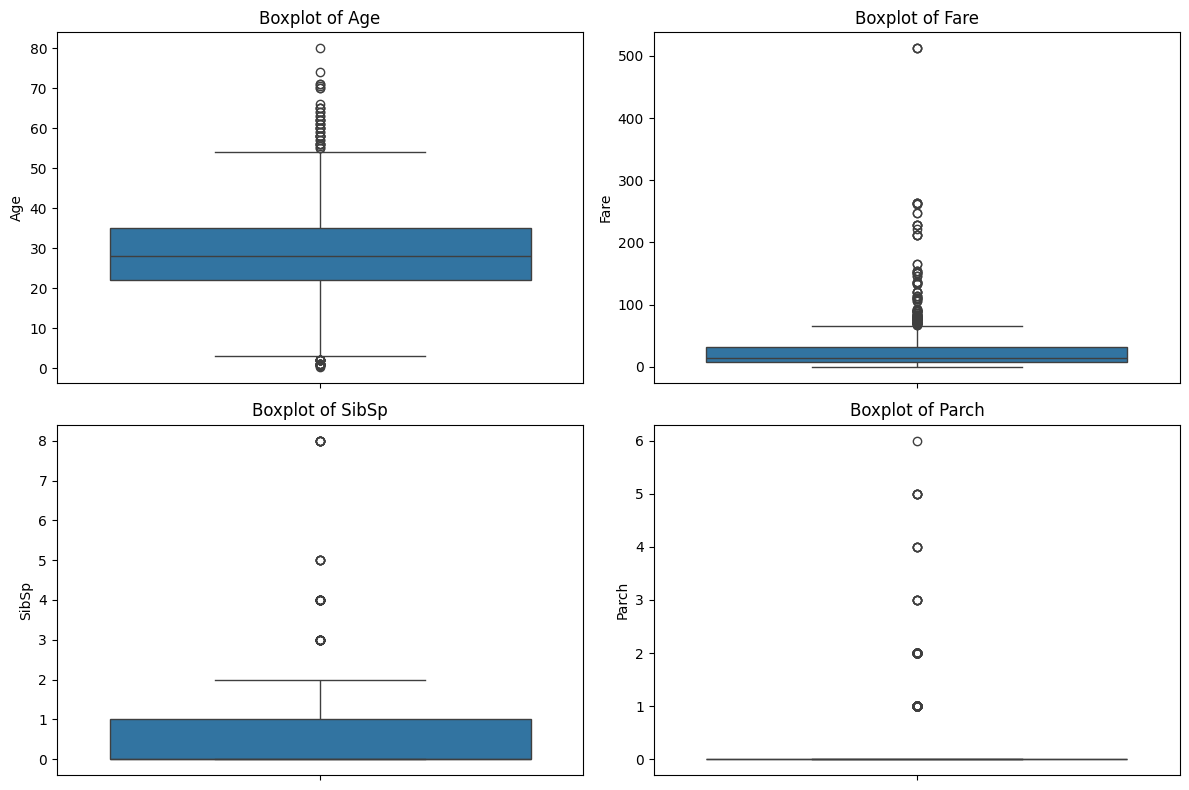

In [12]:
# Visualize outliers using boxplots

outlier_columns = ["Age", "Fare", "SibSp", "Parch"]

plt.figure(figsize=(12, 8))

for i, column in enumerate(outlier_columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

plt.tight_layout()
plt.show()

In [13]:
# Detect outliers using the IQR method

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")

Age: 66 outliers
Fare: 116 outliers
SibSp: 46 outliers
Parch: 213 outliers


In [14]:
# Remove outliers using the IQR method

initial_rows = df.shape[0]

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

final_rows = df.shape[0]
rows_removed = initial_rows - final_rows

print("Outliers removed successfully!")
print("Rows before outlier removal:", initial_rows)
print("Rows after outlier removal:", final_rows)
print("Rows removed:", rows_removed)

Outliers removed successfully!
Rows before outlier removal: 891
Rows after outlier removal: 577
Rows removed: 314


In [15]:
# Verify the cleaned dataset

print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (577, 9)

Missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Data types:
Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [16]:
# Standardize numerical features

scaler = StandardScaler()

features_to_scale = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Numerical features standardized successfully!")
print(df.head())

Numerical features standardized successfully!
   Survived   Pclass       Age     SibSp  Parch      Fare  Sex_male  \
0         0  0.67833 -0.854761  1.800735    0.0 -0.609448      True   
2         1  0.67833 -0.386610 -0.448235    0.0 -0.555858     False   
3         1 -2.04917  0.666730  1.800735    0.0  3.030715     False   
4         0  0.67833  0.666730 -0.448235    0.0 -0.545934      True   
5         0  0.67833 -0.152535 -0.448235    0.0 -0.513517      True   

   Embarked_Q  Embarked_S  
0       False        True  
2       False        True  
3       False        True  
4       False        True  
5        True       False  


In [17]:
# Final verification of the preprocessed dataset

print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFinal columns:")
print(df.columns.tolist())

print("\nFirst 5 rows of the preprocessed dataset:")
display(df.head())

Final dataset shape: (577, 9)

Missing values:
Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Final columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

First 5 rows of the preprocessed dataset:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0.67833,-0.854761,1.800735,0.0,-0.609448,True,False,True
2,1,0.67833,-0.386610,-0.448235,0.0,-0.555858,False,False,True
3,1,-2.04917,0.666730,1.800735,0.0,3.030715,False,False,True
4,0,0.67833,0.666730,-0.448235,0.0,-0.545934,True,False,True
5,0,0.67833,-0.152535,-0.448235,0.0,-0.513517,True,True,False


In [18]:
# Save the final preprocessed dataset

df.to_csv("Titanic_Preprocessed.csv", index=False)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [19]:
# Verify the saved preprocessed dataset

import os

if os.path.exists("Titanic_Preprocessed.csv"):
    print("Titanic_Preprocessed.csv is available in the project folder.")
else:
    print("File was not created.")

Titanic_Preprocessed.csv is available in the project folder.


# Conclusion

The Titanic dataset was successfully cleaned and prepared for machine learning.

Missing values were handled using median and mode imputation, categorical variables were converted into numerical features using one-hot encoding, and numerical features were standardized using StandardScaler.

Outliers were identified using boxplots and the IQR method and were removed from the dataset. The final preprocessed dataset contains no missing values and is ready for further machine learning analysis.